---
title: "Jupyter Feature Tour"
author: "Spencer Boucher"
date: "2026-06-13"
description: "A Jupyter notebook that exercises the full Quarto-style rendering pipeline, including outputs."
categories:
  - jupyter
  - notebooks
  - showcase
featured: false
format:
  toc: true
  toc-depth: 4
  toc-title: "On this page"
  code-fold: false
  code-tools: false
  code-line-numbers: true
execute:
  echo: true
  warning: true
  error: true
  output: true
  include: true
---

# Jupyter feature tour

This post is authored as a **Jupyter** notebook (`.ipynb`) and rendered through the blog's
*Quarto-style* pipeline by `@blog/notebook-parser` — the **same** renderer used for marimo
notebooks. It exists to exercise as many rendering features as possible in one place.

Read more in the [Quarto docs](https://quarto.org) or browse the other [projects](/projects).

## Prose, lists, and quotes

Inline formatting works: **bold**, *italic*, ***both***, and `inline code`.

An unordered list:

- first item
- second item, with some `code`
- third item

An ordered list:

1. step one
2. step two
3. step three

> Blockquotes render too — handy for asides and pull quotes.

## Math

### Inline

Euler's identity $e^{i\pi} + 1 = 0$ renders inline via KaTeX.

### Display

$$
\int_0^1 x^2 \, dx = \frac{1}{3}
\qquad
\sum_{k=1}^{n} k = \frac{n(n+1)}{2}
$$

## Heading levels

The table of contents is built from markdown headings, so every level is available
for structure.

#### Level four
##### Level five
###### Level six

## Callouts

Four Quarto callout types are supported, plus custom titles and collapsing.

:::{.callout-note}
A **note** callout. It can contain markdown and even math like $a^2 + b^2 = c^2$.
:::

:::{.callout-tip}
## A tip with a custom title
The first `## ` line inside a callout becomes its title.
:::

:::{.callout-warning}
A **warning** callout — use these to flag gotchas.
:::

:::{.callout-important collapse="true"}
An **important**, collapsible callout. It starts collapsed; click to expand.
:::

## Tables

GFM tables become sortable, paginated interactive tables.

| Feature   | Renders as         | Interactive? |
|-----------|--------------------|--------------|
| Headings  | h1–h6 + ToC        | no           |
| Tables    | InteractiveTable   | yes (sort)   |
| Math      | KaTeX              | no           |
| Callouts  | styled blocks      | collapsible  |

## Code and outputs

Unlike marimo `.py` files, Jupyter notebooks **store their outputs**, so the cells below
render computed results — images, tables, JSON, errors — alongside their code. Per-cell
Quarto `#|` directives control folding and line numbers. A fenced block inside markdown is
highlighted too, but is distinct from a real code cell:

```python
# fenced code block inside markdown
def greet(name):
    return f"hello, {name}"
```

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [2]:
#| code-fold: show
#| code-summary: Compute a sine wave
angles = np.linspace(0, np.pi, 9)
heights = np.sin(angles)
heights

array([0.00000000e+00, 3.82683432e-01, 7.07106781e-01, 9.23879533e-01,
       1.00000000e+00, 9.23879533e-01, 7.07106781e-01, 3.82683432e-01,
       1.22464680e-16])

In [3]:
#| code-fold: hide
for i in range(3):
    print("step", i, "->", i * i)

step 0 -> 0
step 1 -> 1
step 2 -> 4


In [4]:
#| code-line-numbers: false
message = "This cell turns line numbers off with a per-cell directive."
message

'This cell turns line numbers off with a per-cell directive.'

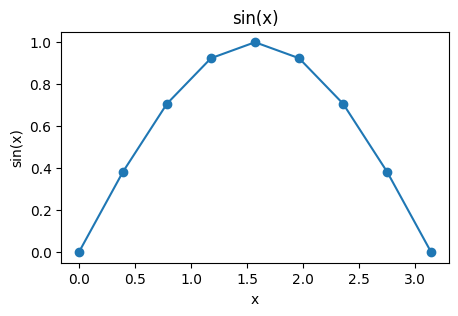

In [5]:
#| label: fig-sine
#| fig-cap: A sine wave sampled at nine points.
#| fig-alt: Line chart of sin(x) from 0 to pi.
fig, ax = plt.subplots(figsize=(5, 3))
ax.plot(angles, heights, marker="o")
ax.set_title("sin(x)")
ax.set_xlabel("x")
ax.set_ylabel("sin(x)")
plt.show()

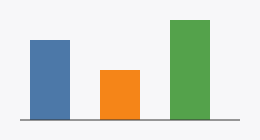

In [6]:
#| label: fig-bars
#| fig-cap: A hand-built SVG bar chart (vector output).
from IPython.display import SVG
SVG("""
<svg xmlns="http://www.w3.org/2000/svg" width="260" height="140" viewBox="0 0 260 140">
  <rect width="260" height="140" fill="#f7f7f9"/>
  <rect x="30"  y="40"  width="40" height="80"  fill="#4c78a8"/>
  <rect x="100" y="70"  width="40" height="50"  fill="#f58518"/>
  <rect x="170" y="20"  width="40" height="100" fill="#54a24b"/>
  <line x1="20" y1="120" x2="240" y2="120" stroke="#333"/>
</svg>
""")

In [7]:
df = pd.DataFrame({
    "feature": ["headings", "tables", "math", "callouts"],
    "renders_as": ["h1-h6 + ToC", "InteractiveTable", "KaTeX", "styled blocks"],
    "interactive": [False, True, False, True],
})
df

,feature,renders_as,interactive
0,headings,h1-h6 + ToC,False
1,tables,InteractiveTable,True
2,math,KaTeX,False
3,callouts,styled blocks,True


In [8]:
from IPython.display import JSON
JSON({"engine": "jupyter", "answer": 42, "nested": {"works": True, "items": [1, 2, 3]}})

<IPython.core.display.JSON object>

In [9]:
import plotly.graph_objects as go
import plotly.io as pio
pio.renderers.default = "plotly_mimetype"
go.Figure(
    data=[go.Bar(x=["a", "b", "c"], y=[3, 1, 2])],
    layout=dict(height=300, title="Plotly bar chart"),
)

In [10]:
#| error: true
1 / 0

ZeroDivisionError: division by zero

In [11]:
import sys
print("this is a stderr warning stream", file=sys.stderr)

this is a stderr warning stream
